NOTE: Python 3.11.2 was used for this project.

In [8]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1 - Topic Definition

Chosen topic: School dropout.

The motivation for choosing school dropout analysis and prediction lies in the importance of understanding the factors that contribute to students abandoning their studies, especially in secondary education. The high dropout rate is a problem that affects not only the individual student but also society as a whole.

## Step 2 - Data Collection

### Overview
This dataset contains relevant information about school dropout of secondary school students. It is used for analysis and prediction of factors contributing to the abandonment of studies.

### Structure
**Column Descriptions:**

- **School:** Name of the school attended

In [9]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [10]:
df=pd.read_csv('student dropout.csv')

In [11]:
df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


## Step 3 – Data Organization

Clean and organize the data.
NOTE: Dataset was already filtered!

In [12]:
print("Quantidade de valores nulos: ")
print(df.isnull().sum())
df.dropna(inplace=True)

Quantidade de valores nulos: 
School                         0
Gender                         0
Age                            0
Address                        0
Family_Size                    0
Parental_Status                0
Mother_Education               0
Father_Education               0
Mother_Job                     0
Father_Job                     0
Reason_for_Choosing_School     0
Guardian                       0
Travel_Time                    0
Study_Time                     0
Number_of_Failures             0
School_Support                 0
Family_Support                 0
Extra_Paid_Class               0
Extra_Curricular_Activities    0
Attended_Nursery               0
Wants_Higher_Education         0
Internet_Access                0
In_Relationship                0
Family_Relationship            0
Free_Time                      0
Going_Out                      0
Weekend_Alcohol_Consumption    0
Weekday_Alcohol_Consumption    0
Health_Status                  0
Number_of_Abs

## Step 4 - Data Presentation

Creating an initial heatmap to visualize the correlation between dataset variables. This visualization is essential to identify which variables have stronger relationships, providing valuable insights into the factors that influence school dropout.

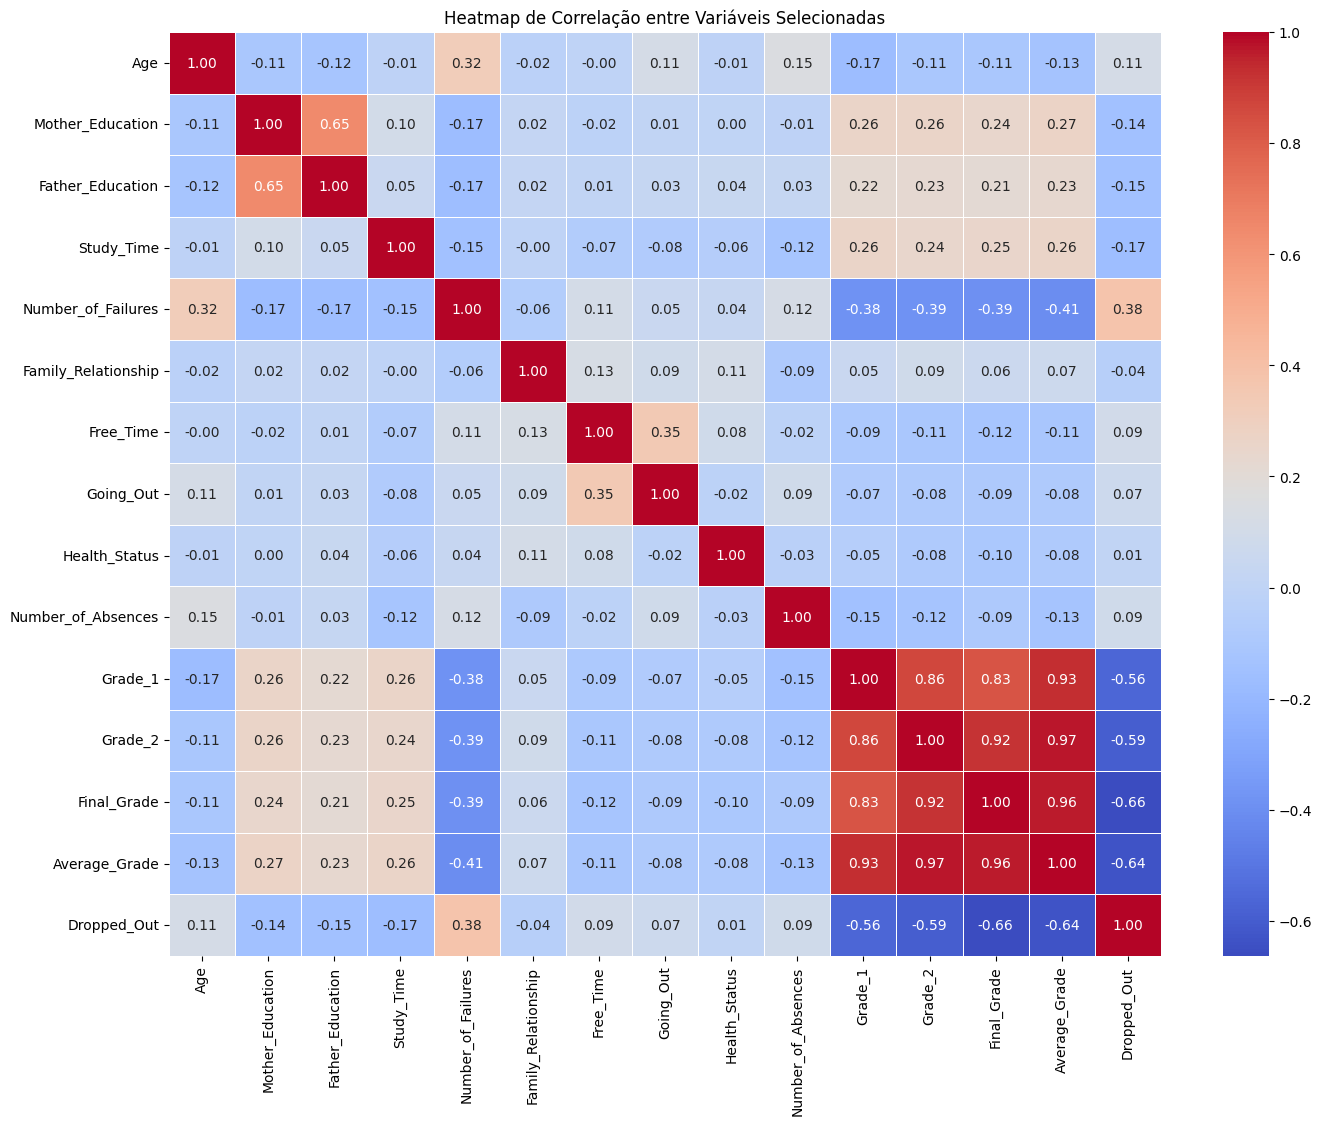

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate the average grades
df['Average_Grade'] = df[['Grade_1', 'Grade_2', 'Final_Grade']].mean(axis=1)

# Convert non-numeric columns to numeric using get_dummies
df_encoded = pd.get_dummies(df, columns=['School', 'Gender', 'Address', 'Family_Size', 'Parental_Status', 'Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian', 'School_Support', 'Family_Support', 'Extra_Paid_Class', 'Extra_Curricular_Activities', 'Attended_Nursery', 'Wants_Higher_Education', 'Internet_Access', 'In_Relationship'], drop_first=True)

# Recalculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Select a subset of variables for the heatmap
selected_columns = ['Age', 'Mother_Education', 'Father_Education', 'Study_Time', 'Number_of_Failures', 'Family_Relationship', 'Free_Time', 'Going_Out', 'Health_Status', 'Number_of_Absences','Grade_1','Grade_2','Final_Grade','Average_Grade', 'Dropped_Out']

# Calculate the correlation matrix for selected variables
correlation_matrix_selected = df_encoded[selected_columns].corr()

# Generate the heatmap for the selected correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_selected, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de Correlação entre Variáveis Selecionadas')
plt.show()

Relating parental education to the school dropout rate is based on the premise that parents' educational level can significantly influence their children's academic performance and continuity of studies. Parents with higher education tend to value education more and provide better support.

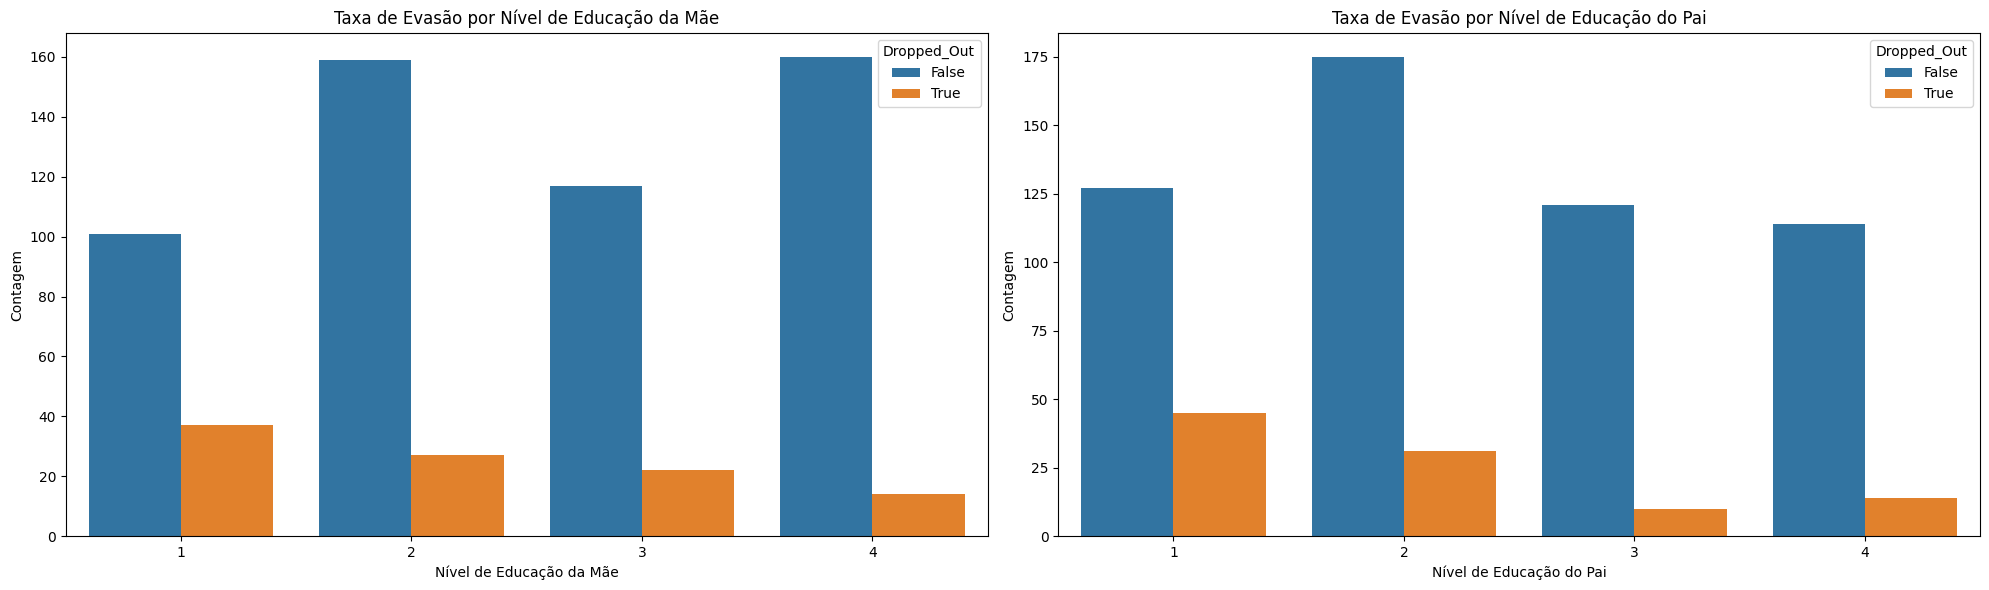

In [14]:

df_filtered = df[(df['Mother_Education'] != 0) & (df['Father_Education'] != 0)]

# 1. Influence of Socioeconomic Factors:
# Grouped bar chart: Compare dropout rate across different parental education levels.
plt.figure(figsize=(20, 6))

# Grouped bar chart: Compare dropout rate across different mother's education levels.
plt.subplot(1, 2, 1)
sns.countplot(data=df_filtered, x='Mother_Education', hue='Dropped_Out')
plt.title('Taxa de Evasão por Nível de Educação da Mãe')
plt.xlabel('Nível de Educação da Mãe')
plt.ylabel('Contagem')

# Grouped bar chart: Compare dropout rate across different father's education levels.
plt.subplot(1, 2, 2)
sns.countplot(data=df_filtered, x='Father_Education', hue='Dropped_Out')
plt.title('Taxa de Evasão por Nível de Educação do Pai')
plt.xlabel('Nível de Educação do Pai')
plt.ylabel('Contagem')

plt.tight_layout()
plt.show()


Based on the generated chart, we can observe the relationship between parents' education level (mother and father) and the school dropout rate.

Dropout Rate by Mother's Education Level:

* There is a clear trend of reduction in dropout rate as the mother's education level increases.

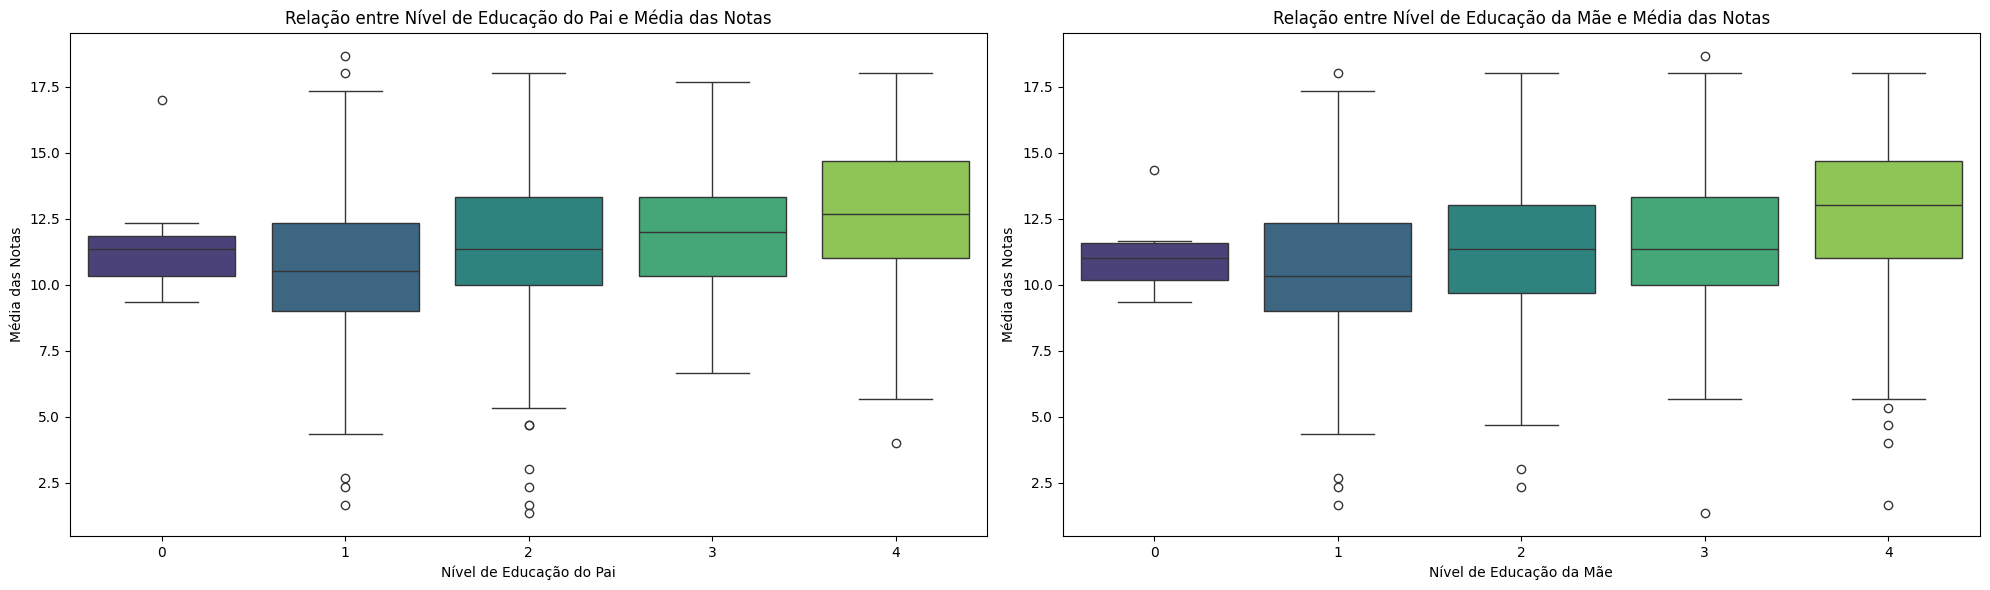

In [15]:
plt.figure(figsize=(20, 6))

# Boxplot for Father's Education Level and Average Grades
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Father_Education', y='Average_Grade', palette='viridis')
plt.title('Relação entre Nível de Educação do Pai e Média das Notas')
plt.xlabel('Nível de Educação do Pai')
plt.ylabel('Média das Notas')

# Boxplot for Mother's Education Level and Average Grades
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Mother_Education', y='Average_Grade', palette='viridis')
plt.title('Relação entre Nível de Educação da Mãe e Média das Notas')
plt.xlabel('Nível de Educação da Mãe')
plt.ylabel('Média das Notas')

plt.tight_layout()
plt.show()

Similarly, we can relate parents' education level to the student's average grades. Conclusion: the higher the parents' education level, the better the children's grades.

Next, we will analyze the relationship between the number of failures (failures) and the students' average grades.

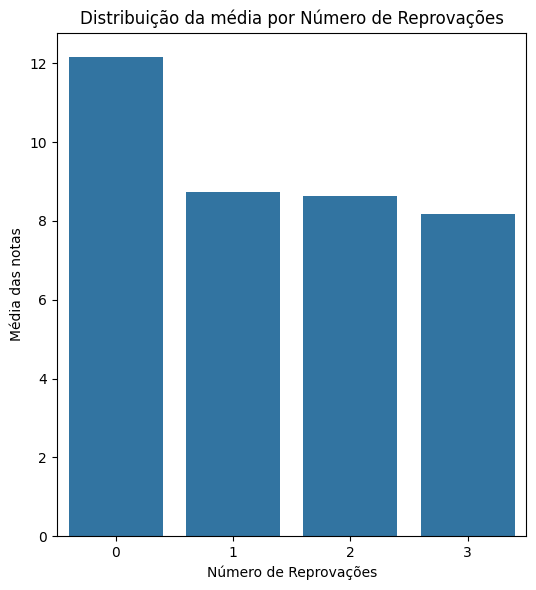

In [16]:
# Bar chart: Relationship between number of failures and grades (Grade_1, Grade_2, Final_Grade)
plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
sns.barplot(data=df, x='Number_of_Failures', y='Average_Grade', ci=None)
plt.title('Distribuição da média por Número de Reprovações')
plt.xlabel('Número de Reprovações')
plt.ylabel('Média das notas')


plt.tight_layout()
plt.show()


The relationship between the number of failures and average grades is a crucial aspect of understanding students' academic performance. In general, average grades tend to decrease as the number of failures increases.

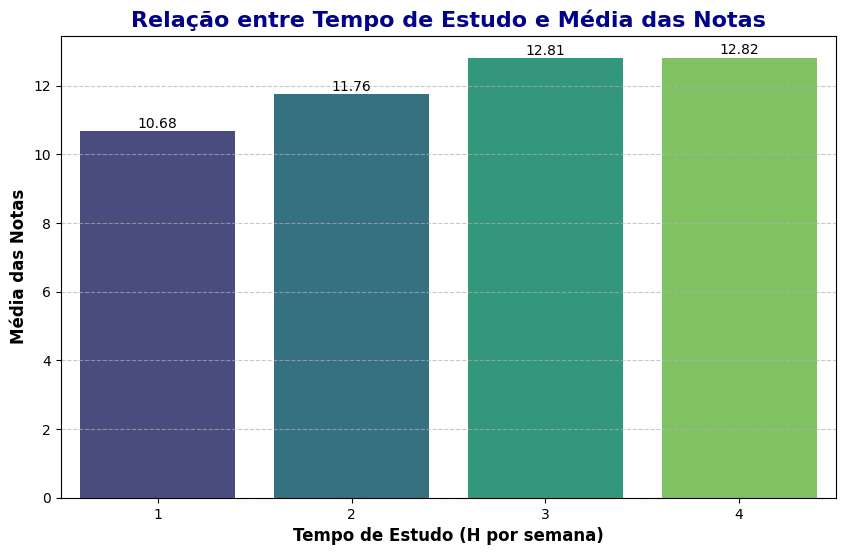

In [17]:
plt.figure(figsize=(10, 6))

# Define new color palette
new_colors = sns.color_palette("viridis", 4)

# Plot the bar chart
sns.barplot(data=df, x='Study_Time', y='Average_Grade', palette=new_colors, ci=None)

# Add data labels
for index, row in df.groupby('Study_Time')['Average_Grade'].mean().reset_index().iterrows():
    plt.text(row.name, row.Average_Grade + 0.1, round(row.Average_Grade, 2), color='black', ha="center")

# Customize the chart
plt.title('Relação entre Tempo de Estudo e Média das Notas', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Tempo de Estudo (H por semana)', fontsize=12, fontweight='bold')
plt.ylabel('Média das Notas', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


Relating individual study time to average grades, we reach the obvious conclusion: the more hours dedicated to studying, the higher the grades.

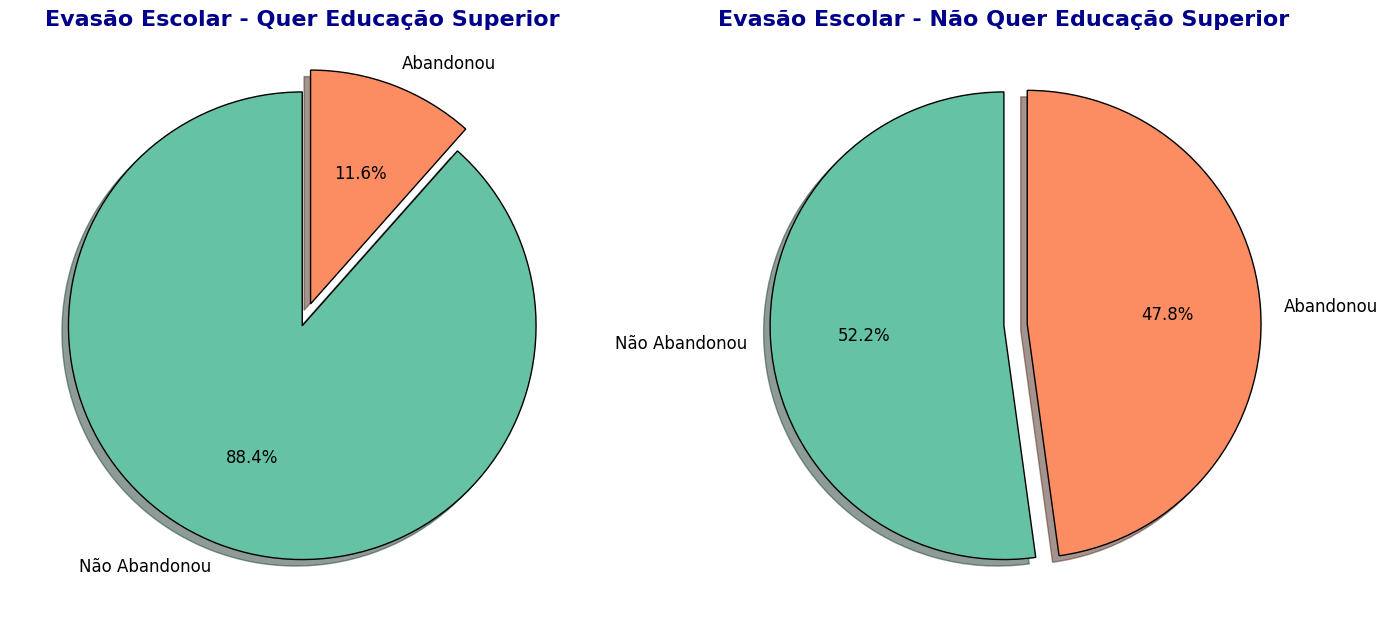

In [18]:
# Pie chart: Relationship between "Wanting better education" and school dropout
plt.figure(figsize=(14, 7))

# Count school dropout for those who want and do not want better education
dropout_counts = df.groupby('Wants_Higher_Education')['Dropped_Out'].value_counts().unstack()

# Define new color palette
new_colors = sns.color_palette("Set2", 2)

# Plot pie chart for those who want better education
plt.subplot(1, 2, 1)
dropout_counts.loc['yes'].plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=new_colors, labels=['Não Abandonou', 'Abandonou'], shadow=True, explode=(0, 0.1), wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 12}, pctdistance=0.6)
plt.title('Evasão Escolar - Quer Educação Superior', fontsize=16, fontweight='bold', color='darkblue')
plt.ylabel('')  # Remove o rótulo do eixo y

# Plot pie chart for those who do not want better education
plt.subplot(1, 2, 2)
dropout_counts.loc['no'].plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=new_colors, labels=['Não Abandonou', 'Abandonou'], shadow=True, explode=(0, 0.1), wedgeprops={'edgecolor': 'black'}, textprops={'fontsize': 12}, pctdistance=0.6)
plt.title('Evasão Escolar - Não Quer Educação Superior', fontsize=16, fontweight='bold', color='darkblue')
plt.ylabel('')  # Remove o rótulo do eixo y

plt.tight_layout()
plt.show()

The pie charts illustrate the relationship between the desire for higher education and the school dropout rate.

### School Dropout - Wants Higher Education
In the left chart, we observe the distribution of school dropout among students who wish to pursue higher education.

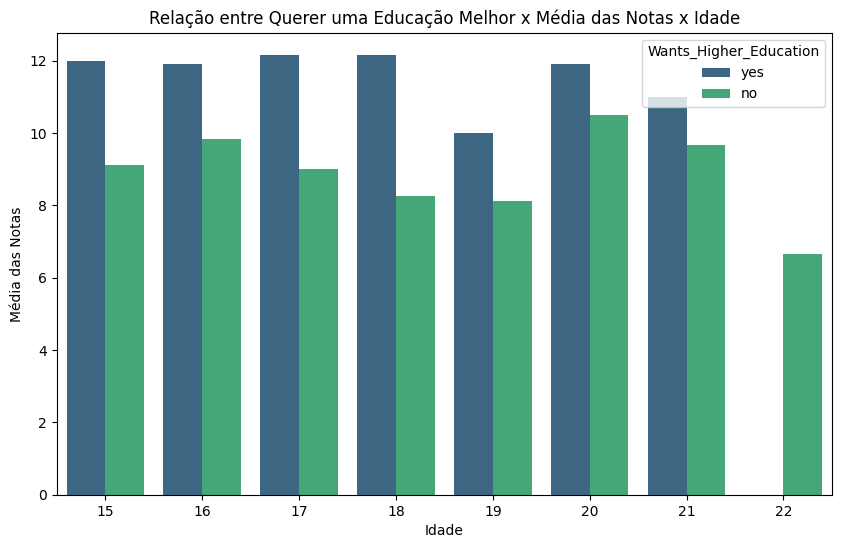

In [19]:
df_filtered_age = df[(df['Age'] >= 14) & (df['Age'] <= 22)]

plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered_age, x='Age', hue='Wants_Higher_Education', y='Average_Grade', palette='viridis', ci=None)
plt.title('Relação entre Querer uma Educação Melhor x Média das Notas x Idade')
plt.xlabel('Idade')
plt.ylabel('Média das Notas')
plt.show()


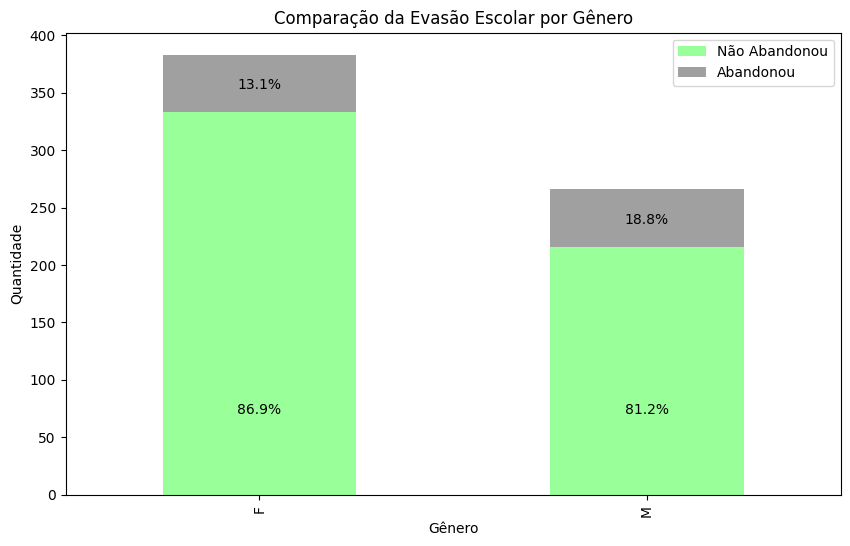

In [20]:
# Comparison of school dropout by gender in terms of quantity
plt.figure(figsize=(10, 6))

# Define dropout_counts_gender
dropout_counts_gender = df.groupby('Gender')['Dropped_Out'].value_counts().unstack()

# Bar chart for school dropout by gender
dropout_counts_gender.plot(kind='bar', stacked=True, color=['#99ff99', '#A0A0A0'], ax=plt.gca())
plt.title('Comparação da Evasão Escolar por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(['Não Abandonou', 'Abandonou'])

# Add percentages
for i in range(dropout_counts_gender.shape[0]):
    total = dropout_counts_gender.iloc[i].sum()
    for j in range(dropout_counts_gender.shape[1]):
        count = dropout_counts_gender.iloc[i, j]
        percentage = 100 - (count / total * 100)
        plt.text(i, count + 20, f'{percentage:.1f}%', ha='center')

plt.show()


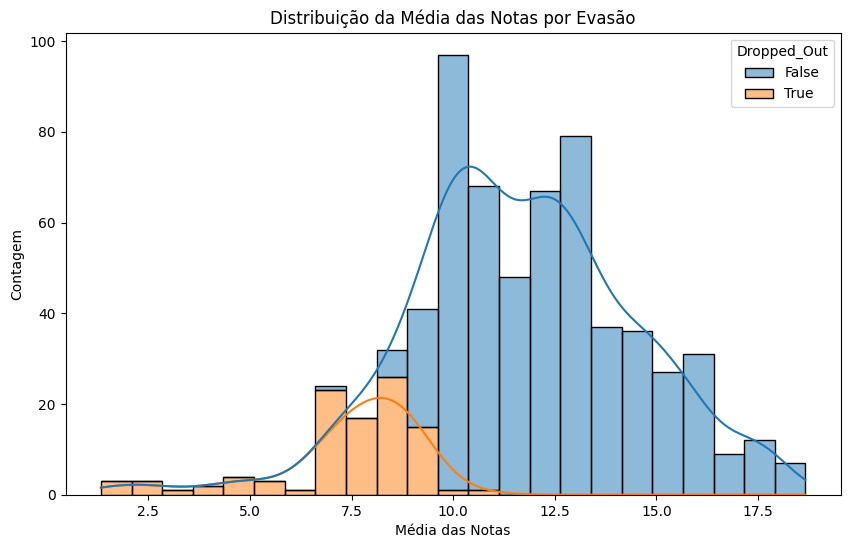

In [21]:
# Plot histogram of average of three grades with Dropped_Out
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Average_Grade', hue='Dropped_Out', multiple='stack', kde=True)
plt.title('Distribuição da Média das Notas por Evasão')
plt.xlabel('Média das Notas')
plt.ylabel('Contagem')
plt.show()

## Step 5 - Results Analysis

### Measures of Position and Dispersion

To complement the analysis, we calculate some measures of position (mean, median) and dispersion (standard deviation, variance) for the most relevant variables in the dataset.

In [22]:

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate measures of position and dispersion
medidas_posicao_dispersao = numeric_df.describe().T
medidas_posicao_dispersao['variancia'] = numeric_df.var()
medidas_posicao_dispersao = medidas_posicao_dispersao[['mean', '50%', 'std', 'variancia']]
medidas_posicao_dispersao.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Variância']

print(medidas_posicao_dispersao)



                                 Média    Mediana  Desvio Padrão  Variância
Age                          16.744222  17.000000       1.218138   1.483859
Mother_Education              2.514638   2.000000       1.134552   1.287208
Father_Education              2.306626   2.000000       1.099931   1.209848
Travel_Time                   1.568567   1.000000       0.748660   0.560492
Study_Time                    1.930663   2.000000       0.829510   0.688086
Number_of_Failures            0.221880   0.000000       0.593235   0.351928
Family_Relationship           3.930663   4.000000       0.955717   0.913395
Free_Time                     3.180277   3.000000       1.051093   1.104796
Going_Out                     3.184900   3.000000       1.175766   1.382426
Weekend_Alcohol_Consumption   1.502311   1.000000       0.924834   0.855319
Weekday_Alcohol_Consumption   2.280431   2.000000       1.284380   1.649632
Health_Status                 3.536210   4.000000       1.446259   2.091665
Number_of_Ab

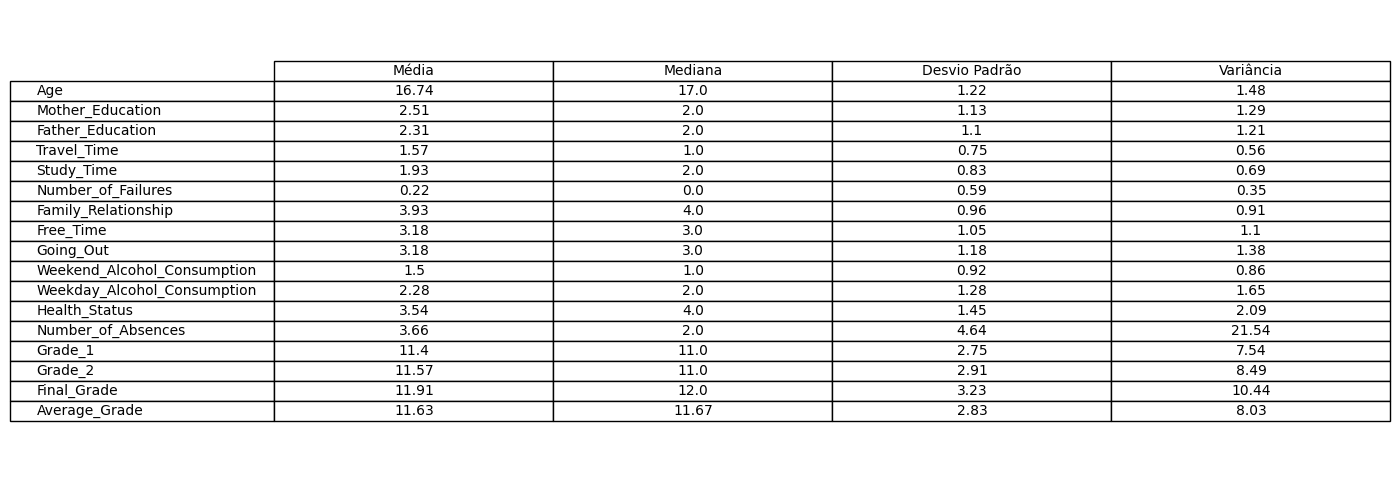

In [23]:
# Assuming medidas_posicao_dispersao is a DataFrame
# Round table values to 2 decimal places (or as needed)
medidas_posicao_dispersao = medidas_posicao_dispersao.round(2)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Remove the axes
ax.axis('off')

# Add the table to the axis
table = ax.table(cellText=medidas_posicao_dispersao.values,
                 colLabels=medidas_posicao_dispersao.columns,
                 rowLabels=medidas_posicao_dispersao.index,
                 cellLoc='center',
                 loc='center')

# Adjust the table layout
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Display the figure
plt.show()

Based on the calculated measures of position and dispersion, the data appears to provide a consistent and reliable view of the analyzed variables. The presence of close mean and median values for most variables suggests no major asymmetries, indicating reliable data.

### Conclusion

The analysis of school dropout data revealed several important correlations between socioeconomic, academic, and family variables. Main conclusions:

1. **Parental Education**: Higher parental education levels are associated with lower dropout rates.